# 1. Exploratory Data Analysis

This notebook explores the BirdClef 2026 dataset to understand its structure, characteristics, and prepare for model development.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.1 Define Paths

In [2]:
BASE_DIR = Path('/home/kwierman/Desktop/Projects/BirdClef')
TRAIN_AUDIO_DIR = BASE_DIR / 'train_audio'
TRAIN_SOUNDSCAPES_DIR = BASE_DIR / 'train_soundscapes'
TEST_SOUNDSCAPES_DIR = BASE_DIR / 'test_soundscapes'

# CSV files
TRAIN_CSV = BASE_DIR / 'train.csv'
TAXONOMY_CSV = BASE_DIR / 'taxonomy.csv'
SAMPLE_SUBMISSION_CSV = BASE_DIR / 'sample_submission.csv'
TRAIN_SOUNDSCAPES_LABELS_CSV = BASE_DIR / 'train_soundscapes_labels.csv'

## 1.2 Load Datasets

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
taxonomy_df = pd.read_csv(TAXONOMY_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_CSV)
train_soundscapes_labels = pd.read_csv(TRAIN_SOUNDSCAPES_LABELS_CSV)

print("Train CSV shape:", train_df.shape)
print("Taxonomy shape:", taxonomy_df.shape)
print("Sample Submission shape:", sample_submission.shape)
print("Train Soundscapes Labels shape:", train_soundscapes_labels.shape)

Train CSV shape: (35549, 15)
Taxonomy shape: (234, 5)
Sample Submission shape: (3, 235)
Train Soundscapes Labels shape: (1478, 4)


## 1.3 Explore Train CSV

In [4]:
print("Train DataFrame columns:")
print(train_df.columns.tolist())
print("\nFirst few rows:")
train_df.head()

Train DataFrame columns:
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

First few rows:


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [5]:
print("\nData types:")
print(train_df.dtypes)
print("\nMissing values:")
print(train_df.isnull().sum())


Data types:
primary_label           str
secondary_labels        str
type                    str
latitude            float64
longitude           float64
scientific_name         str
common_name             str
class_name              str
inat_taxon_id         int64
author                  str
license                 str
rating              float64
url                     str
filename                str
collection              str
dtype: object

Missing values:
primary_label       0
secondary_labels    0
type                0
latitude            0
longitude           0
scientific_name     0
common_name         0
class_name          0
inat_taxon_id       0
author              0
license             0
rating              0
url                 0
filename            0
collection          0
dtype: int64


## 1.4 Species Distribution

In [6]:
species_counts = train_df['primary_label'].value_counts()
print(f"Number of unique species in train.csv: {len(species_counts)}")
print(f"\nTop 10 species by count:")
print(species_counts.head(10))
print(f"\nBottom 10 species by count:")
print(species_counts.tail(10))

Number of unique species in train.csv: 206

Top 10 species by count:
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
Name: count, dtype: int64

Bottom 10 species by count:
primary_label
64898      3
74580      3
sptnig1    3
209233     2
24321      2
70711      2
116570     1
23150      1
23724      1
516975     1
Name: count, dtype: int64


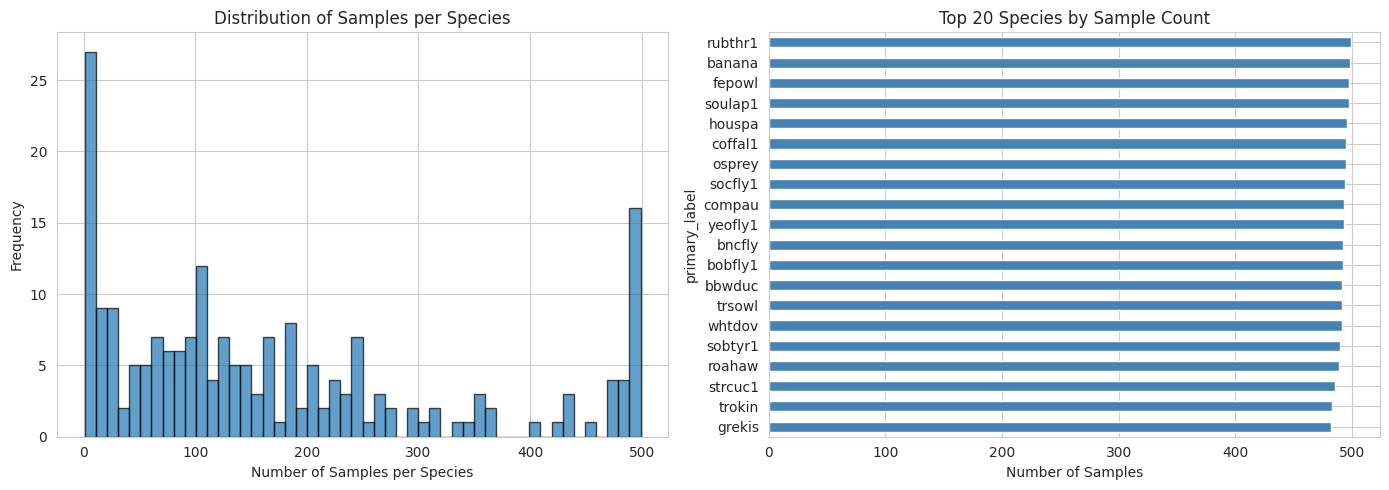

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of species counts
axes[0].hist(species_counts.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Samples per Species')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Samples per Species')

# Top 20 species
species_counts.head(20).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Top 20 Species by Sample Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'figures' / 'species_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1.5 Class Distribution (Taxonomy)

Class distribution in taxonomy:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


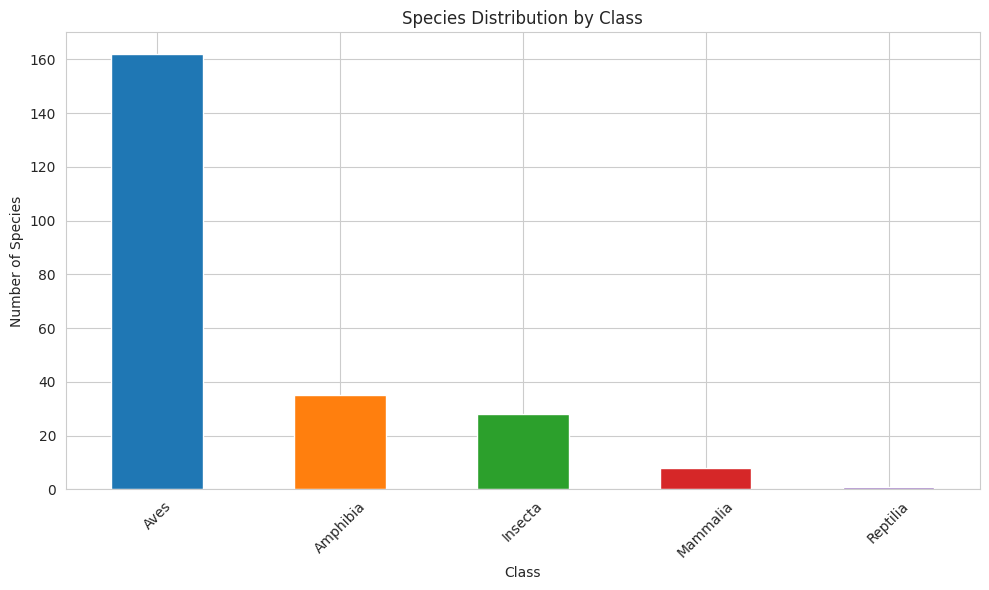

In [8]:
class_counts = taxonomy_df['class_name'].value_counts()
print("Class distribution in taxonomy:")
print(class_counts)

fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax.set_xlabel('Class')
ax.set_ylabel('Number of Species')
ax.set_title('Species Distribution by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'figures' / 'class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1.6 Collection Distribution

Collection distribution:
collection
XC      23043
iNat    12506
Name: count, dtype: int64


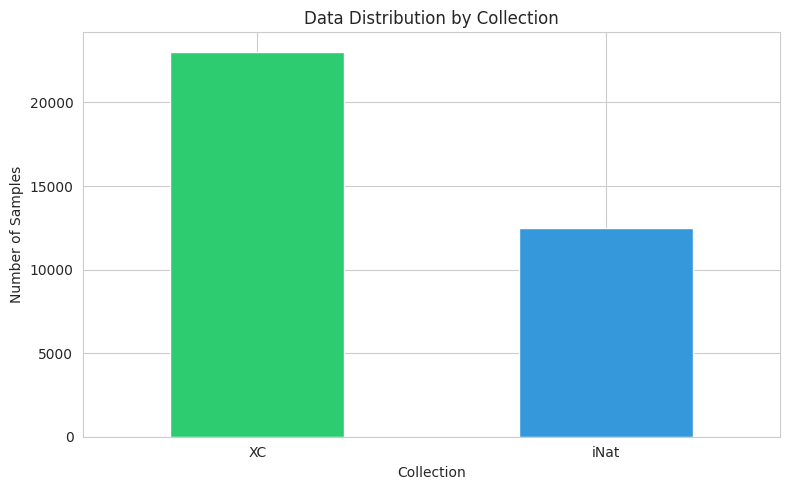

In [9]:
collection_counts = train_df['collection'].value_counts()
print("Collection distribution:")
print(collection_counts)

fig, ax = plt.subplots(figsize=(8, 5))
collection_counts.plot(kind='bar', color=['#2ecc71', '#3498db'])
ax.set_xlabel('Collection')
ax.set_ylabel('Number of Samples')
ax.set_title('Data Distribution by Collection')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'figures' / 'collection_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1.7 Rating Distribution

Rating distribution:
rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64


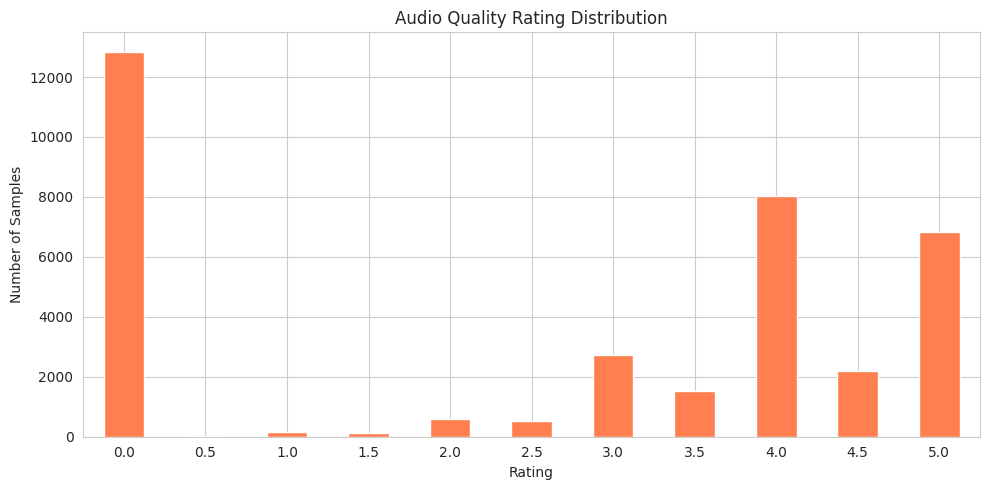

In [10]:
rating_counts = train_df['rating'].value_counts().sort_index()
print("Rating distribution:")
print(rating_counts)

fig, ax = plt.subplots(figsize=(10, 5))
rating_counts.plot(kind='bar', color='coral')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Samples')
ax.set_title('Audio Quality Rating Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'figures' / 'rating_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1.8 Geographic Distribution

Records with valid coordinates: 35549


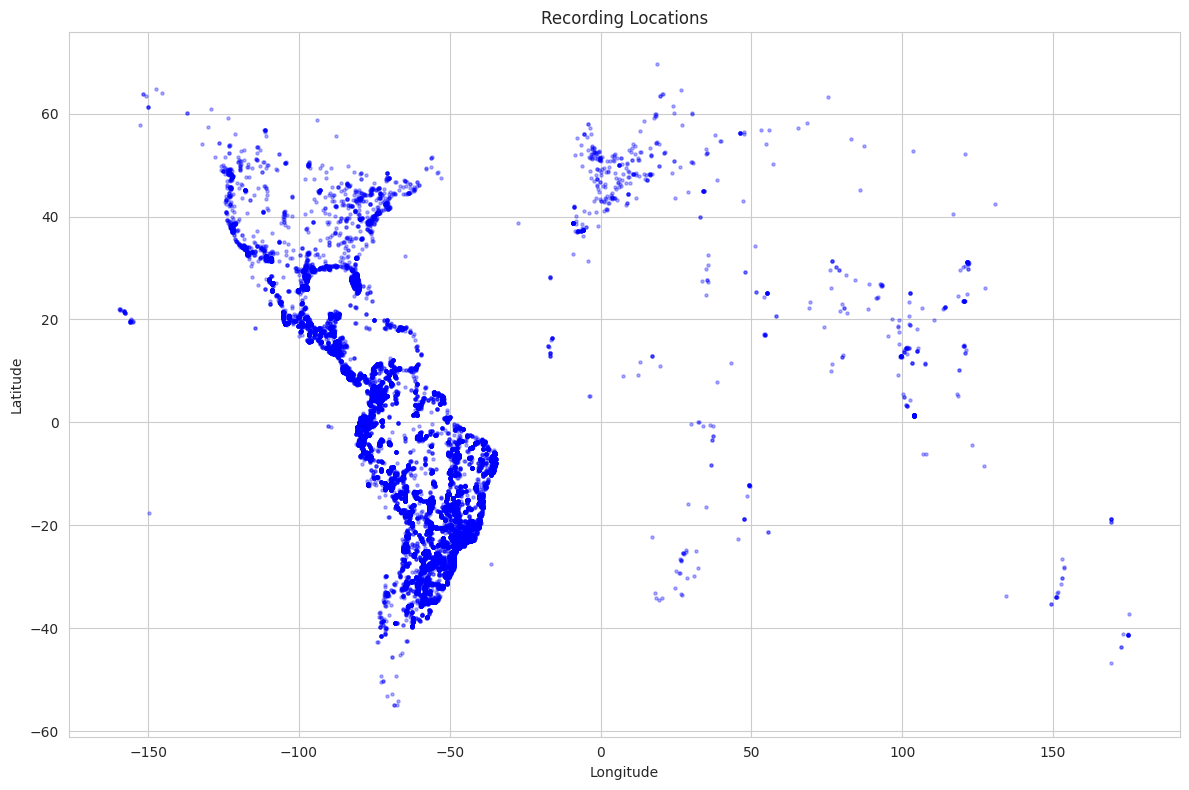


Latitude range: -54.86 to 69.58
Longitude range: -159.66 to 175.32


In [11]:
# Filter out missing coordinates
geo_df = train_df.dropna(subset=['latitude', 'longitude'])
print(f"Records with valid coordinates: {len(geo_df)}")

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(geo_df['longitude'], geo_df['latitude'], 
                      alpha=0.3, s=5, c='blue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Recording Locations')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'figures' / 'geographic_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nLatitude range: {geo_df['latitude'].min():.2f} to {geo_df['latitude'].max():.2f}")
print(f"Longitude range: {geo_df['longitude'].min():.2f} to {geo_df['longitude'].max():.2f}")

## 1.9 Train Soundscapes Analysis

In [12]:
print("Train Soundscapes Labels sample:")
print(train_soundscapes_labels.head(10))

print(f"\nNumber of unique soundscape files: {train_soundscapes_labels['filename'].nunique()}")
print(f"Number of labeled segments: {len(train_soundscapes_labels)}")
print(f"\nSegment duration: 5 seconds")
print(f"Total audio duration per file: 60 seconds (12 segments)")

Train Soundscapes Labels sample:
                                    filename     start       end  \
0  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:00  00:00:05   
1  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:05  00:00:10   
2  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:10  00:00:15   
3  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:15  00:00:20   
4  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:20  00:00:25   
5  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:25  00:00:30   
6  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:30  00:00:35   
7  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:35  00:00:40   
8  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:40  00:00:45   
9  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:45  00:00:50   

                    primary_label  
0  22961;23158;24321;517063;65380  
1  22961;23158;24321;517063;65380  
2  22961;23158;24321;517063;65380  
3  22961;23158;24321;517063;65380  
4  22961;23158;24321;517063;65380  
5 

In [13]:
# Analyze species in soundscapes
all_labels = []
for labels in train_soundscapes_labels['primary_label']:
    all_labels.extend(labels.split(';'))

soundscape_species = pd.Series(all_labels).value_counts()
print(f"Number of unique species in train soundscapes: {len(soundscape_species)}")
print(f"\nTop 20 species in soundscapes:")
print(soundscape_species.head(20))

Number of unique species in train soundscapes: 75

Top 20 species in soundscapes:
65380         666
517063        626
22973         426
555146        420
23158         350
24279         346
24321         344
22967         310
66971         298
47158son25    168
1491113       158
chacha1       130
whtdov        126
47158son07     96
47158son17     86
undtin1        86
compau         76
litnig1        74
22961          72
47158son11     72
Name: count, dtype: int64


## 1.10 Sample Submission Analysis

In [14]:
print("Sample submission columns (first 10):")
print(sample_submission.columns[:10].tolist())
print(f"\nTotal number of species columns: {len(sample_submission.columns) - 1}")
print(f"\nNumber of rows: {len(sample_submission)}")
print("\nFirst few row_ids:")
print(sample_submission['row_id'].head())

Sample submission columns (first 10):
['row_id', '1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961']

Total number of species columns: 234

Number of rows: 3

First few row_ids:
0     BC2026_Test_0001_S05_20250227_010002_5
1    BC2026_Test_0001_S05_20250227_010002_10
2    BC2026_Test_0001_S05_20250227_010002_15
Name: row_id, dtype: str


In [15]:
# Parse row_id to understand the test data structure
row_ids = sample_submission['row_id'].str.rsplit('_', n=1)
test_files = row_ids.str[0].unique()
print(f"Number of test soundscape files: {len(test_files)}")
print(f"\nNumber of segments per file: {len(sample_submission) // len(test_files)}")

# Segment times
segment_times = row_ids.str[-1].unique()
print(f"\nSegment end times: {sorted(segment_times)}")

Number of test soundscape files: 1

Number of segments per file: 3

Segment end times: ['10', '15', '5']


## 1.11 Audio File Inspection

In [16]:
import subprocess

# Count audio files in train_audio
train_audio_files = list(TRAIN_AUDIO_DIR.rglob('*.ogg'))
print(f"Number of audio files in train_audio: {len(train_audio_files)}")

# Count audio files in train_soundscapes
train_soundscape_files = list(TRAIN_SOUNDSCAPES_DIR.glob('*.ogg'))
print(f"Number of audio files in train_soundscapes: {len(train_soundscape_files)}")

# Check test_soundscapes
test_soundscape_files = list(TEST_SOUNDSCAPES_DIR.glob('*.ogg'))
print(f"Number of audio files in test_soundscapes: {len(test_soundscape_files)}")

Number of audio files in train_audio: 35549
Number of audio files in train_soundscapes: 10658
Number of audio files in test_soundscapes: 0


In [17]:
# Check if torchaudio is available
try:
    import torchaudio
    print("torchaudio is available")
    
    # Load a sample audio file
    waveform, sample_rate = torchaudio.load(str(train_audio_files[0]))
    print(f"\nSample audio info:")
    print(f"  File: {train_audio_files[0].name}")
    print(f"  Shape: {waveform.shape}")
    print(f"  Sample rate: {sample_rate} Hz")
    print(f"  Duration: {waveform.shape[1] / sample_rate:.2f} seconds")
except ImportError:
    print("torchaudio not available, trying scipy")
    import scipy.io.wavfile as wav
    # Note: ogg files need to be converted first

torchaudio is available
torchaudio not available, trying scipy


## 1.12 Data Summary Statistics

In [18]:
summary_stats = {
    'Total training samples in train.csv': len(train_df),
    'Unique species in train.csv': train_df['primary_label'].nunique(),
    'Total species to predict (taxonomy)': len(taxonomy_df),
    'Audio files in train_audio': len(train_audio_files),
    'Audio files in train_soundscapes': len(train_soundscape_files),
    'Labeled segments in train_soundscapes': len(train_soundscapes_labels),
    'Unique species in train_soundscapes': len(soundscape_species),
    'Test files in sample_submission': len(test_files),
}

summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Value'])
print(summary_df.to_string(index=False))

                               Metric  Value
  Total training samples in train.csv  35549
          Unique species in train.csv    206
  Total species to predict (taxonomy)    234
           Audio files in train_audio  35549
     Audio files in train_soundscapes  10658
Labeled segments in train_soundscapes   1478
  Unique species in train_soundscapes     75
      Test files in sample_submission      1


## 1.13 Secondary Labels Analysis

In [19]:
# Analyze secondary labels
secondary_labels_not_empty = train_df[train_df['secondary_labels'].str.len() > 2]  # '[]' has 2 chars
print(f"Records with secondary labels: {len(secondary_labels_not_empty)}")
print(f"Percentage: {len(secondary_labels_not_empty) / len(train_df) * 100:.2f}%")

# Extract all secondary labels
all_secondary = []
for labels in secondary_labels_not_empty['secondary_labels']:
    # Parse the list-like string
    labels_clean = labels.strip('[]').replace("'", "").split(', ')
    for label in labels_clean:
        if label and label != '':
            all_secondary.append(label.strip())

secondary_counts = pd.Series(all_secondary).value_counts()
print(f"\nTop 20 secondary labels:")
print(secondary_counts.head(20))

Records with secondary labels: 4372
Percentage: 12.30%

Top 20 secondary labels:
grekis     624
whtdov     468
undtin1    315
yecpar     226
rufhor2    225
saffin     183
picpig2    172
trokin     171
soulap1    154
grasal3    151
chobla1    150
rubthr1    128
scadov1    127
banana     118
fepowl     104
barant1     96
thlwre1     95
greant1     94
yebela1     88
bobfly1     84
Name: count, dtype: int64


## 1.14 Save EDA Summary

In [20]:
# Save summary statistics
summary_df.to_csv(BASE_DIR / 'notebooks' / 'data' / 'eda_summary.csv', index=False)

# Save species counts
species_counts.to_csv(BASE_DIR / 'notebooks' / 'data' / 'species_counts.csv', header=True)

print("EDA summary saved to notebooks/data/")
print("\n✅ Exploratory Data Analysis Complete!")

EDA summary saved to notebooks/data/

✅ Exploratory Data Analysis Complete!
